<a href="https://colab.research.google.com/github/VedanshSawner/NeRF/blob/main/NeRF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os, sys, json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import imageio.v2 as imageio
import time

tf.compat.v1.enable_v2_behavior()
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
!pip install -q tensorflow


In [ ]:
!unzip /content/000a6774ed02497391fc40ef378faef6.zip -d /content/extracted_folder/


Archive:  /content/000a6774ed02497391fc40ef378faef6.zip
   creating: /content/extracted_folder/000a6774ed02497391fc40ef378faef6/
   creating: /content/extracted_folder/000a6774ed02497391fc40ef378faef6/depth/
  inflating: /content/extracted_folder/000a6774ed02497391fc40ef378faef6/depth/r_0.npy  
  inflating: /content/extracted_folder/000a6774ed02497391fc40ef378faef6/depth/r_1.npy  
  inflating: /content/extracted_folder/000a6774ed02497391fc40ef378faef6/depth/r_10.npy  
  inflating: /content/extracted_folder/000a6774ed02497391fc40ef378faef6/depth/r_11.npy  
  inflating: /content/extracted_folder/000a6774ed02497391fc40ef378faef6/depth/r_12.npy  
  inflating: /content/extracted_folder/000a6774ed02497391fc40ef378faef6/depth/r_13.npy  
  inflating: /content/extracted_folder/000a6774ed02497391fc40ef378faef6/depth/r_14.npy  
  inflating: /content/extracted_folder/000a6774ed02497391fc40ef378faef6/depth/r_15.npy  
  inflating: /content/extracted_folder/000a6774ed02497391fc40ef378faef6/depth/r_16

Image size: 200x200, focal = 173.21
Loaded images: (75, 200, 200, 3)
Loaded poses: (75, 4, 4)
Using first 40 images for this experiment.


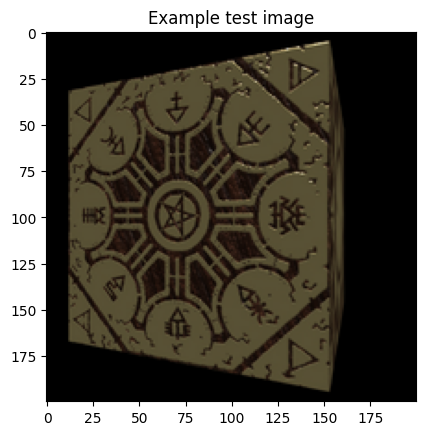

In [ ]:
dataset_path = "/content/extracted_folder/000a6774ed02497391fc40ef378faef6"  # <-- change this if needed
json_path = os.path.join(dataset_path, "transforms.json")

with open(json_path, "r") as f:
    meta = json.load(f)

camera_angle_x = meta["camera_angle_x"]
frames = meta["frames"]

# Load first image to get resolution
first_img_path = os.path.join(dataset_path, frames[0]["file_path"].replace("\\", "/"))
img0 = imageio.imread(first_img_path)
H, W = img0.shape[:2]
focal = 0.5 * W / np.tan(0.5 * camera_angle_x)
print(f"Image size: {W}x{H}, focal = {focal:.2f}")

# Load all images and poses
images, poses = [], []
for fdata in frames:
    img_path = os.path.join(dataset_path, fdata["file_path"].replace("\\", "/"))
    img = imageio.imread(img_path).astype(np.float32) / 255.0
    images.append(img)
    poses.append(np.array(fdata["transform_matrix"], dtype=np.float32))

images = np.stack(images, 0)
poses = np.stack(poses, 0)
print("Loaded images:", images.shape)
print("Loaded poses:", poses.shape)

images = images[:40]
poses = poses[:40]
print(f"Using first 40 images for this experiment.")

# Pick one test image and pose
testimg, testpose = images[-1], poses[-1]
images = images[:-1, ..., :3]
poses = poses[:-1]

plt.imshow(testimg)
plt.title("Example test image")
plt.show()

In [ ]:
def posenc(x):
  rets = [x]
  for i in range(L_embed):
    for fn in [tf.sin, tf.cos]:
      rets.append(fn(2.**i * x))
  return tf.concat(rets, -1)

L_embed = 10
embed_fn = posenc
# L_embed = 0
# embed_fn = tf.identity

def init_model(D=8, W=256):
    relu = tf.keras.layers.ReLU()
    dense = lambda W=W, act=relu : tf.keras.layers.Dense(W, activation=act)

    inputs = tf.keras.Input(shape=(3 + 3*2*L_embed,))
    outputs = inputs
    for i in range(D):
        outputs = dense()(outputs)
        if i%4==0 and i>0:
            outputs = tf.keras.layers.Concatenate(axis=-1)([outputs, inputs])
    outputs = dense(4, act=None)(outputs)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


def get_rays(H, W, focal, c2w):
    i, j = tf.meshgrid(tf.range(W, dtype=tf.float32), tf.range(H, dtype=tf.float32), indexing='xy')
    # Use the focal, H, and W variables from your data loader
    dirs = tf.stack([(i-W*.5)/focal, -(j-H*.5)/focal, -tf.ones_like(i)], -1)
    rays_d = tf.reduce_sum(dirs[..., np.newaxis, :] * c2w[:3,:3], -1)
    rays_o = tf.broadcast_to(c2w[:3,-1], tf.shape(rays_d))
    return rays_o, rays_d


def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, rand=False):

    def batchify(fn, chunk=1024*32):
        return lambda inputs : tf.concat([fn(inputs[i:i+chunk]) for i in range(0, inputs.shape[0], chunk)], 0)

    # Compute 3D query points
    z_vals = tf.linspace(near, far, N_samples)
    if rand:
      z_vals += tf.random.uniform(list(rays_o.shape[:-1]) + [N_samples]) * (far-near)/N_samples
    pts = rays_o[...,None,:] + rays_d[...,None,:] * z_vals[...,:,None]

    # Run network
    pts_flat = tf.reshape(pts, [-1,3])
    pts_flat = embed_fn(pts_flat)
    raw = batchify(network_fn)(pts_flat)
    raw = tf.reshape(raw, list(pts.shape[:-1]) + [4])

    # Compute opacities and colors
    sigma_a = tf.nn.relu(raw[...,3] + 0.1)
    rgb = tf.math.sigmoid(raw[...,:3])

    # Do volume rendering
    dists = tf.concat([z_vals[..., 1:] - z_vals[..., :-1], tf.broadcast_to([1e10], z_vals[...,:1].shape)], -1)
    alpha = 1.-tf.exp(-sigma_a * dists)
    weights = alpha * tf.math.cumprod(1.-alpha + 1e-10, -1, exclusive=True)

    rgb_map = tf.reduce_sum(weights[...,None] * rgb, -2)
    depth_map = tf.reduce_sum(weights * z_vals, -1)
    acc_map = tf.reduce_sum(weights, -1)

    return rgb_map, depth_map, acc_map

In [ ]:
# --- ADD THIS CODE ---
# Get the translation part of the poses (camera positions)
camera_positions = poses[:, :3, 3]

# Calculate the distance from the origin (0,0,0)
distances = np.linalg.norm(camera_positions, axis=1)

# Find the min and max distances
min_dist = np.min(distances)
max_dist = np.max(distances)

print(f"Camera distance from origin - Min: {min_dist:.2f}, Max: {max_dist:.2f}")
# --- END OF SNIPPET ---

Camera distance from origin - Min: 1.80, Max: 1.80


In [ ]:
def sample_random_rays(images, poses, H, W, focal, batch_size=1024):
    img_i = np.random.randint(images.shape[0])
    target = images[img_i]
    pose = poses[img_i]

    rays_o, rays_d = get_rays(H, W, focal, pose)

    # Flatten
    rays_o = tf.reshape(rays_o, [-1, 3])
    rays_d = tf.reshape(rays_d, [-1, 3])
    target = tf.reshape(target, [-1, 3])

    # Choose random rays
    idx = tf.random.uniform(shape=[batch_size], maxval=rays_o.shape[0], dtype=tf.int32)

    return tf.gather(rays_o, idx), tf.gather(rays_d, idx), tf.gather(target, idx)

model = init_model()
optimizer = tf.keras.optimizers.Adam(5e-4)

N_samples = 64
N_iters = 2000
psnrs = []
iternums = []
i_plot = 25

# === IMPORTANT ===
# Adjust near/far planes based on your scene
# Your custom 'transforms.json' might have this info,
# but for now, we'll use the defaults from the original script.
NEAR_PLANE = 0.5
FAR_PLANE = 3.5
# =================

batch_size = 1024   # or 512 if GPU memory is low

t = time.time()
for i in range(N_iters + 1):

    rays_o, rays_d, target = sample_random_rays(images, poses, H, W, focal, batch_size)

    with tf.GradientTape() as tape:
        rgb, depth, acc = render_rays(model, rays_o, rays_d,
                                      near=NEAR_PLANE, far=FAR_PLANE,
                                      N_samples=N_samples, rand=True)
        loss = tf.reduce_mean(tf.square(rgb - target))

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))


    if i%i_plot==0:
        print(i, (time.time() - t) / i_plot, 'secs per iter')
        t = time.time()

        # Render the holdout view (testimg, testpose) for logging
        rays_o, rays_d = get_rays(H, W, focal, testpose)
        rgb, depth, acc = render_rays(model, rays_o, rays_d, near=NEAR_PLANE, far=FAR_PLANE, N_samples=N_samples)
        loss = tf.reduce_mean(tf.square(rgb - testimg))
        psnr = -10. * tf.math.log(loss) / tf.math.log(10.)

        psnrs.append(psnr.numpy())
        iternums.append(i)

        plt.figure(figsize=(10,4))
        plt.subplot(121)
        plt.imshow(rgb)
        plt.title(f'Iteration: {i}')
        plt.subplot(122)
        plt.plot(iternums, psnrs)
        plt.title('PSNR')
        plt.show()

print('Done')

interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

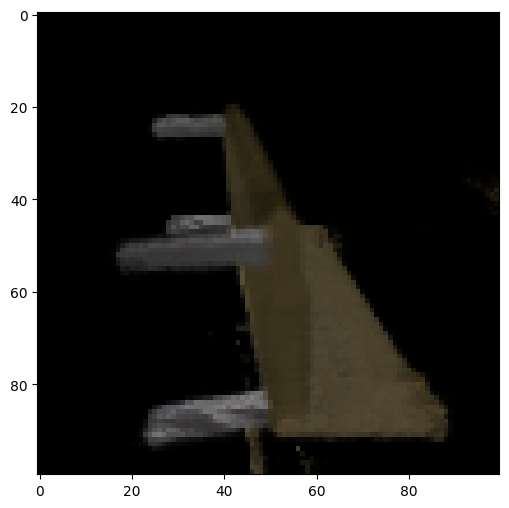

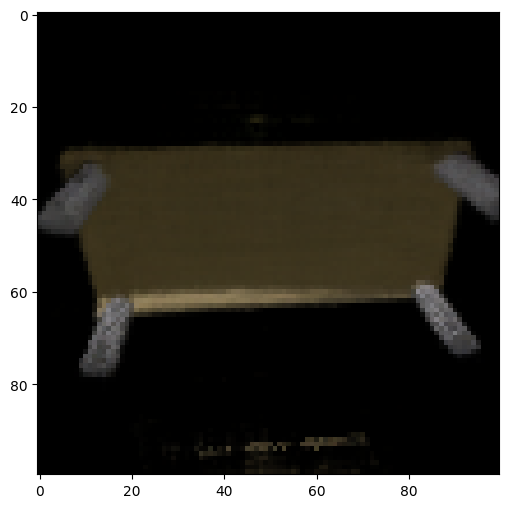

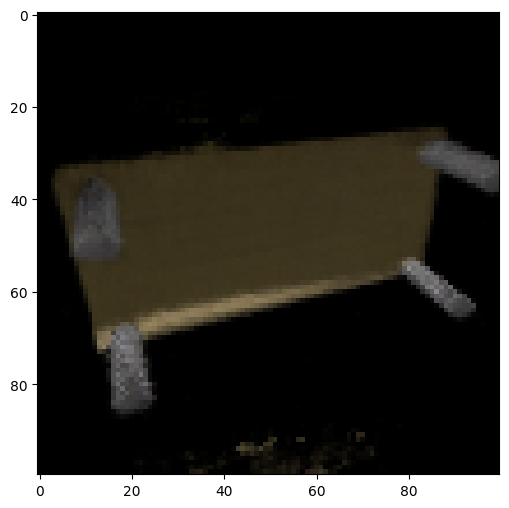

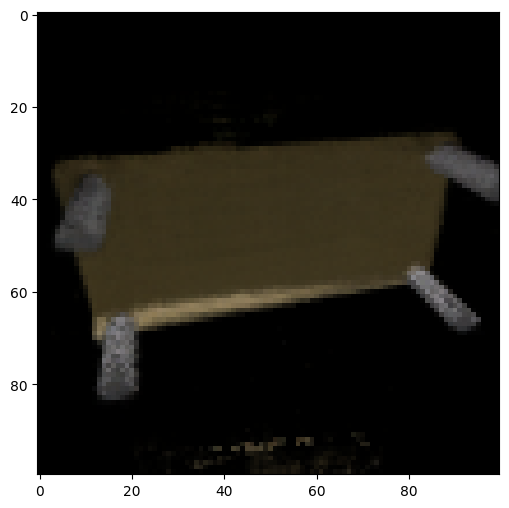

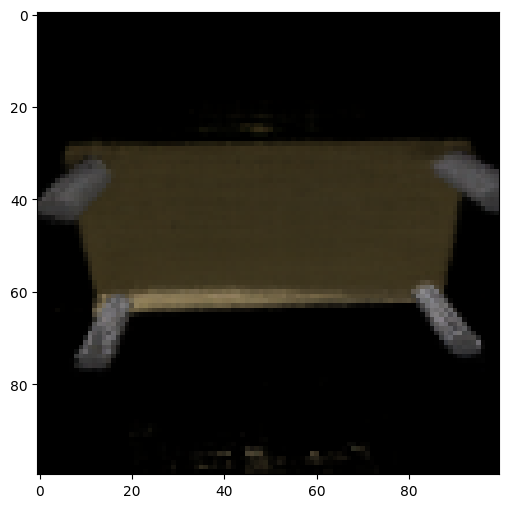

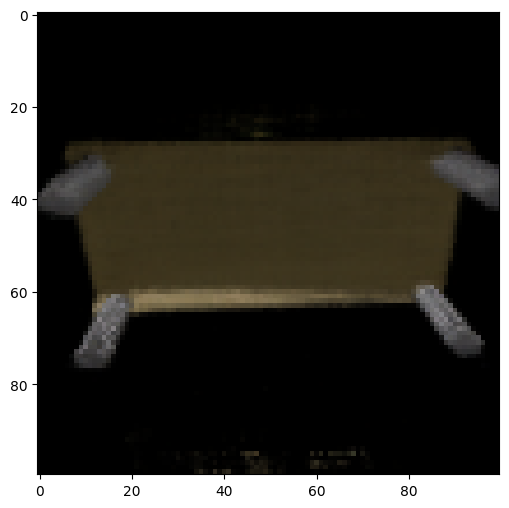

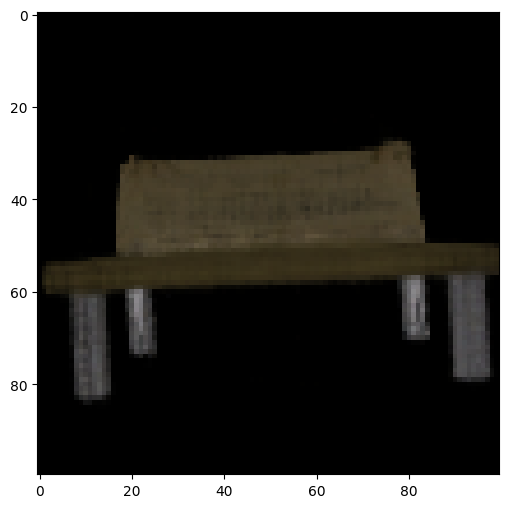

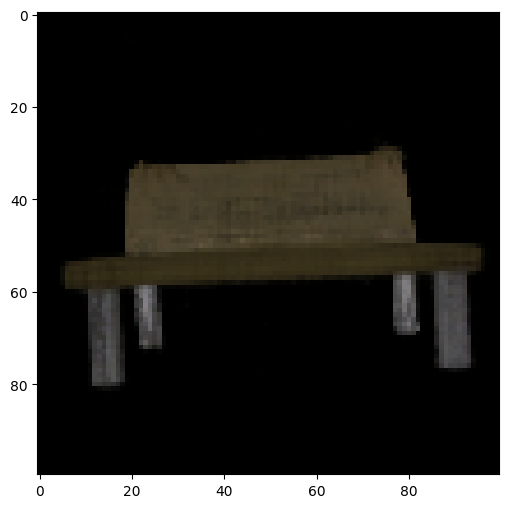

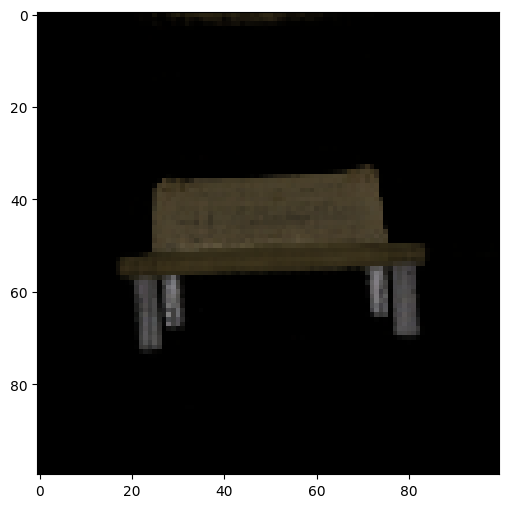

In [ ]:
%matplotlib inline
from ipywidgets import interactive, widgets
import numpy as np # Added this as it's used in pose_spherical
import tensorflow as tf # Added this as it's used in the transform lambdas
import matplotlib.pyplot as plt # Added this as it's used in function f

trans_t = lambda t : tf.convert_to_tensor([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,1,t],
    [0,0,0,1],
], dtype=tf.float32)

rot_phi = lambda phi : tf.convert_to_tensor([
    [1,0,0,0],
    [0,tf.cos(phi),-tf.sin(phi),0],
    [0,tf.sin(phi), tf.cos(phi),0],
    [0,0,0,1],
], dtype=tf.float32)

rot_theta = lambda th : tf.convert_to_tensor([
    [tf.cos(th),0,-tf.sin(th),0],
    [0,1,0,0],
    [tf.sin(th),0, tf.cos(th),0],
    [0,0,0,1],
], dtype=tf.float32)


def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(phi/180.*np.pi) @ c2w
    c2w = rot_theta(theta/180.*np.pi) @ c2w
    c2w = np.array([[-1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]]) @ c2w
    return c2w


def f(**kwargs):
    c2w = pose_spherical(**kwargs)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=NEAR_PLANE, far=FAR_PLANE, N_samples=N_samples)
    img = np.clip(rgb,0,1)

    plt.figure(2, figsize=(20,6))
    plt.imshow(img)
    plt.show()


sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=.01,
)

# You might want to adjust the 'radius' min/max and default value
# based on your scene's scale
names = [
    ['theta', [100., 0., 360]],
    ['phi', [-30., -90, 0]],
    ['radius', [1.8, 1.5, 2.5]], # This 'radius' is the default for the Lego
]

interactive_plot = interactive(f, **{s[0] : sldr(*s[1]) for s in names})
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

In [ ]:
# Generate the video
frames = []
# Use the same radius as the interactive slider default
render_radius = 4.
for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
    c2w = pose_spherical(th, -30., render_radius)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=NEAR_PLANE, far=FAR_PLANE, N_samples=N_samples)
    frames.append((255*np.clip(rgb,0,1)).astype(np.uint8))

import imageio
f = 'video.mp4'
imageio.mimwrite(f, frames, fps=30, quality=7)

In [ ]:
# Display the video in the notebook
mp4 = open('video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)